In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
import re
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from sklearn.preprocessing import minmax_scale
import IPython.display as ipd

plt.rcParams['figure.figsize'] = (20,8)
plt.rcParams['font.size'] = 16
sns.set_style('darkgrid')
warnings.filterwarnings("ignore")

In [2]:
directory = '/kaggle/input/strokeaudio'
data = pd.read_csv("/kaggle/input/strokeaudio/Slutter_vs_Normal/strokeaudio_metadata2.csv")
data['filename'] = data['filename'].apply(lambda x: os.path.join(directory,x))
data

,is_dysarthria,gender,filename
0,dysarthria,male,/kaggle/input/strokeaudio/Slutter_vs_Normal/dy...
1,dysarthria,male,/kaggle/input/strokeaudio/Slutter_vs_Normal/dy...
2,dysarthria,male,/kaggle/input/strokeaudio/Slutter_vs_Normal/dy...
3,dysarthria,male,/kaggle/input/strokeaudio/Slutter_vs_Normal/dy...
4,dysarthria,male,/kaggle/input/strokeaudio/Slutter_vs_Normal/dy...
...,...,...,...
4311,dysarthria,female,/kaggle/input/strokeaudio/Slutter_vs_Normal/dy...
4312,dysarthria,female,/kaggle/input/strokeaudio/Slutter_vs_Normal/dy...
4313,dysarthria,female,/kaggle/input/strokeaudio/Slutter_vs_Normal/dy...
4314,dysarthria,female,/kaggle/input/strokeaudio/Slutter_vs_Normal/dy...


In [3]:
def show_waveplot(audio_path,label,gender):
    x , sr = librosa.load(audio_path)
    plt.figure(figsize=(20, 6))
    librosa.display.waveshow(x, sr=sr)
    plt.title(f"Waveplot: of Class: {label}, Gender: {gender}")

def show_spectrogram(audio_path,label,gender):
    x , sr = librosa.load(audio_path)
    X = librosa.stft(x)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(20,6))
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz',cmap='plasma')
    plt.colorbar()
    plt.title(f"Spectrogram of Class: {label}, Gender: {gender}")
    
def show_zcr(audio_path,label,gender):
    x , sr = librosa.load(audio_path)
    zero_crossings = librosa.zero_crossings(x)
    print("Sum of zero crossing ", zero_crossings.sum())
    plt.figure(figsize=(20, 5))
    plt.title(f'Zero Crossing Rate of Class: {label}, Gender: {gender}')
    zcrs = librosa.feature.zero_crossing_rate(x)
    plt.plot(zcrs[0])
    plt.show()
    
def normalize(x, axis=0):
    return minmax_scale(x, axis=axis)

def show_spectral_centroids(audio_path,label,gender):
    plt.figure(figsize=(20, 5))
    plt.title(f'Spectral Centroids of Class: {label}, Gender: {gender}')
    x , sr = librosa.load(audio_path)
    spectral_centroids = librosa.feature.spectral_centroid(x, sr=sr)[0]
    frames = range(len(spectral_centroids))
    t = librosa.frames_to_time(frames)
    librosa.display.waveshow(x, sr=sr, alpha=0.4)
    plt.plot(t, normalize(spectral_centroids), color='r')
    plt.show()
    
def show_spectral_rolloff(audio_path,label,gender):
    plt.figure(figsize=(20, 5))
    plt.title(f'Spectral Rolloff of Class: {label}, Gender: {gender}')
    x , sr = librosa.load(audio_path)
    spectral_rolloff = librosa.feature.spectral_rolloff(x, sr=sr, roll_percent=0.01)[0]
    frames = range(len(spectral_rolloff))
    t = librosa.frames_to_time(frames)
    librosa.display.waveshow(x, sr=sr, alpha=0.4)
    plt.plot(t, normalize(spectral_rolloff), color='r')
    plt.show()
    
def show_mfccs(audio_path,label,gender):
    plt.figure(figsize=(20, 6))
    plt.title(f'MFCC of Class: {label}, Gender: {gender}')
    x , sr = librosa.load(audio_path)
    mfccs = librosa.feature.mfcc(y=x, sr=sr)
    librosa.display.specshow(mfccs, sr=sr, x_axis='time',cmap='plasma')
    plt.show()
    
def show_melspectro(audio_path,label,gender):
    plt.figure(figsize=(20, 6))
    plt.title(f'Mel Spectro of Class: {label}, Gender: {gender}')
    x , sr = librosa.load(audio_path)
    melspectro = librosa.feature.melspectrogram(y=x, sr=sr)
    librosa.display.specshow(melspectro, sr=sr, x_axis='time',cmap='plasma')
    plt.show()  

In [4]:
data.sample(frac=1).reset_index(drop=True,inplace=True)
male_dysarthric = data[(data['gender']=='male') & (data['is_dysarthria']=='dysarthria')].sample(1)
female_dysarthric = data[(data['gender']=='female') & (data['is_dysarthria']=='dysarthria')].sample(1)
male_ndysarthric = data[(data['gender']=='male') & (data['is_dysarthria']=='non_dysarthria')].sample(1)
female_ndysarthric = data[(data['gender']=='female') & (data['is_dysarthria']=='non_dysarthria')].sample(1)

## Male and Dysarthric

In [5]:
ipd.Audio(male_dysarthric.iloc[0].filename)

## Female and Dysarthric

In [6]:
ipd.Audio(female_dysarthric.iloc[0].filename)

## Male and Non Dysarthric

In [7]:
ipd.Audio(male_ndysarthric.iloc[0].filename)

## Female and Dysarthric

In [8]:
ipd.Audio(female_ndysarthric.iloc[0].filename)

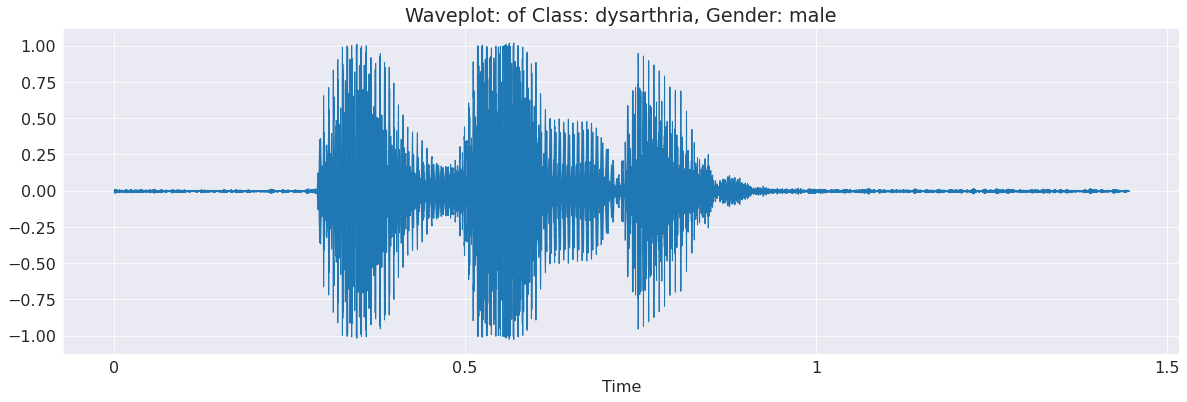

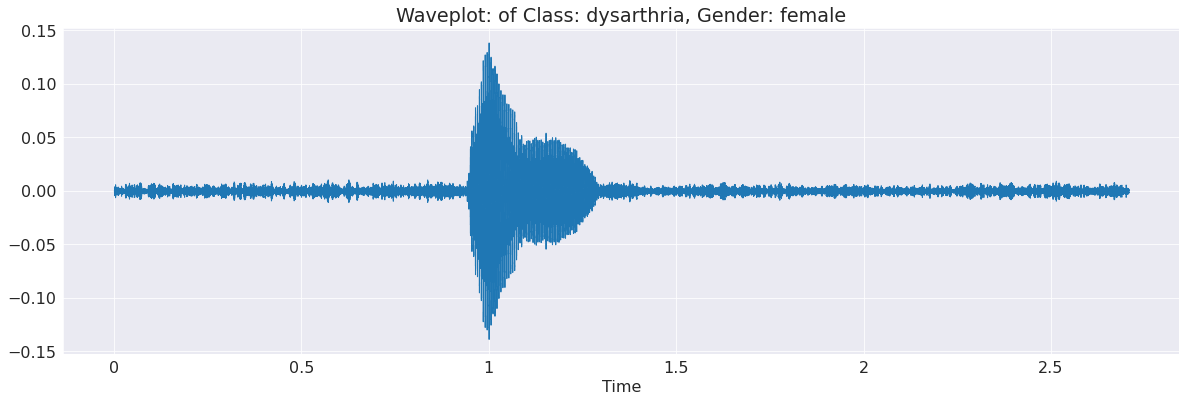

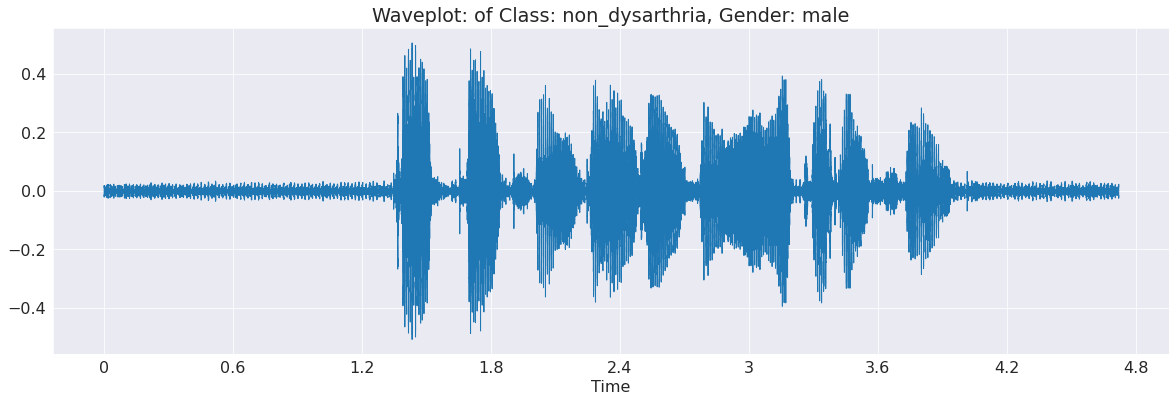

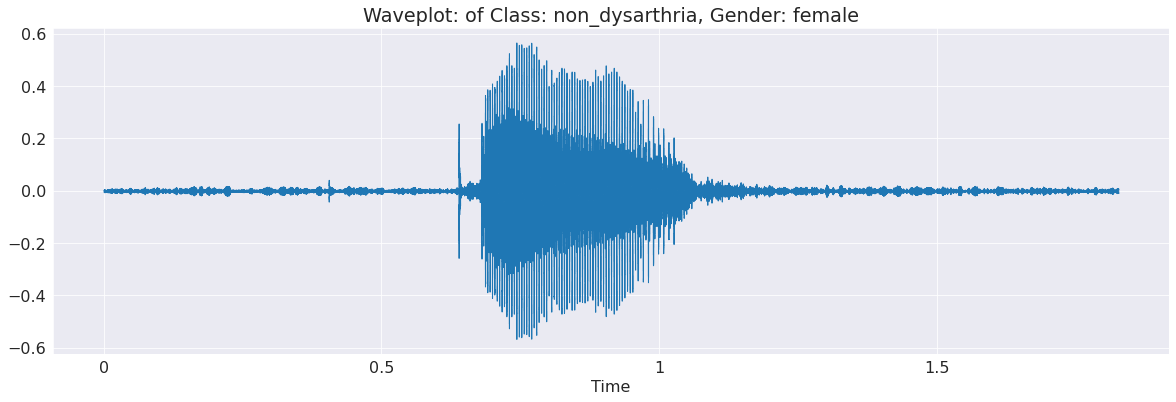

In [9]:
show_waveplot(male_dysarthric.iloc[0].filename, male_dysarthric.iloc[0].is_dysarthria, male_dysarthric.iloc[0].gender)
show_waveplot(female_dysarthric.iloc[0].filename, female_dysarthric.iloc[0].is_dysarthria, female_dysarthric.iloc[0].gender)
show_waveplot(male_ndysarthric.iloc[0].filename, male_ndysarthric.iloc[0].is_dysarthria, male_ndysarthric.iloc[0].gender)
show_waveplot(female_ndysarthric.iloc[0].filename, female_ndysarthric.iloc[0].is_dysarthria, female_ndysarthric.iloc[0].gender)

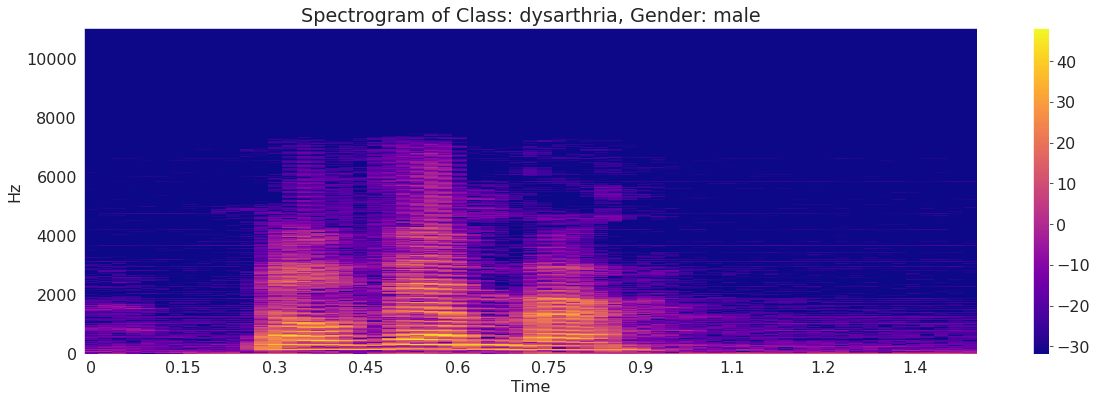

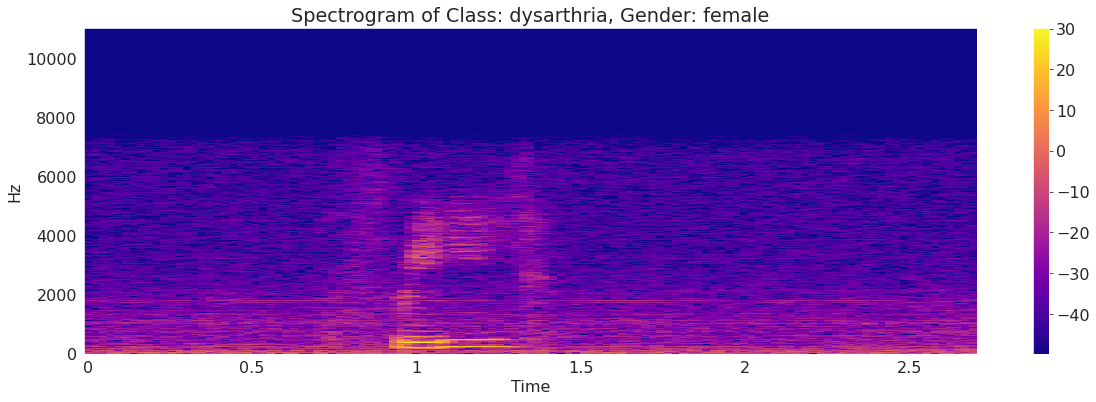

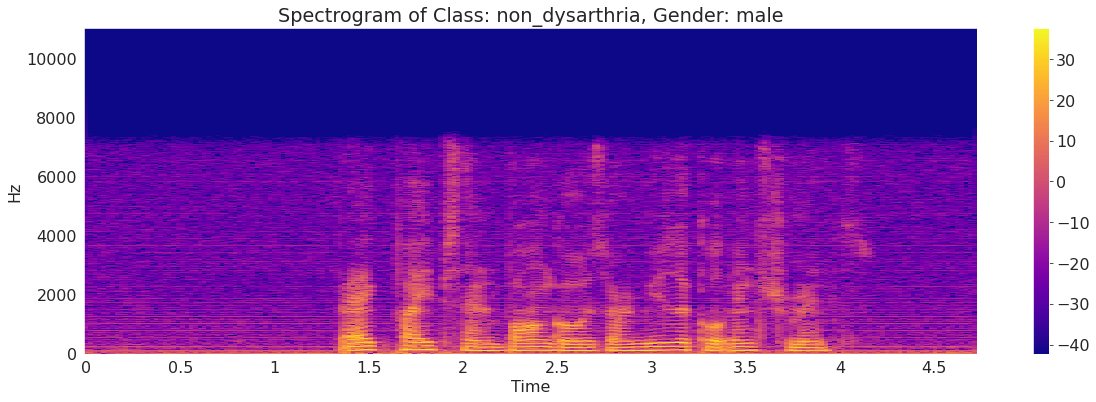

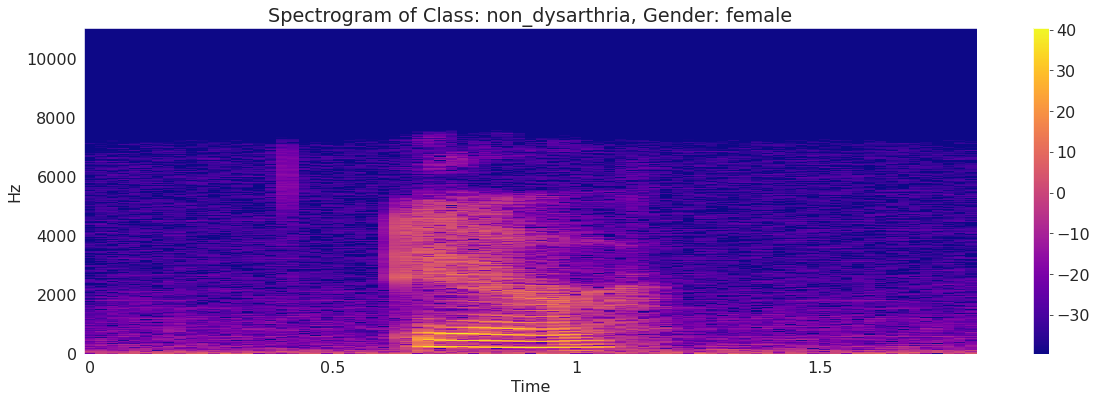

In [10]:
show_spectrogram(male_dysarthric.iloc[0].filename, male_dysarthric.iloc[0].is_dysarthria, male_dysarthric.iloc[0].gender)
show_spectrogram(female_dysarthric.iloc[0].filename, female_dysarthric.iloc[0].is_dysarthria, female_dysarthric.iloc[0].gender)
show_spectrogram(male_ndysarthric.iloc[0].filename, male_ndysarthric.iloc[0].is_dysarthria, male_ndysarthric.iloc[0].gender)
show_spectrogram(female_ndysarthric.iloc[0].filename, female_ndysarthric.iloc[0].is_dysarthria, female_ndysarthric.iloc[0].gender)

Sum of zero crossing  1312


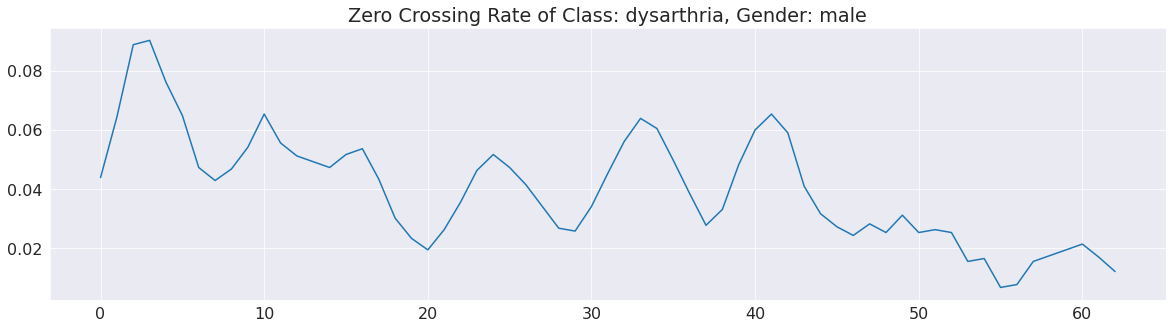

Sum of zero crossing  3028


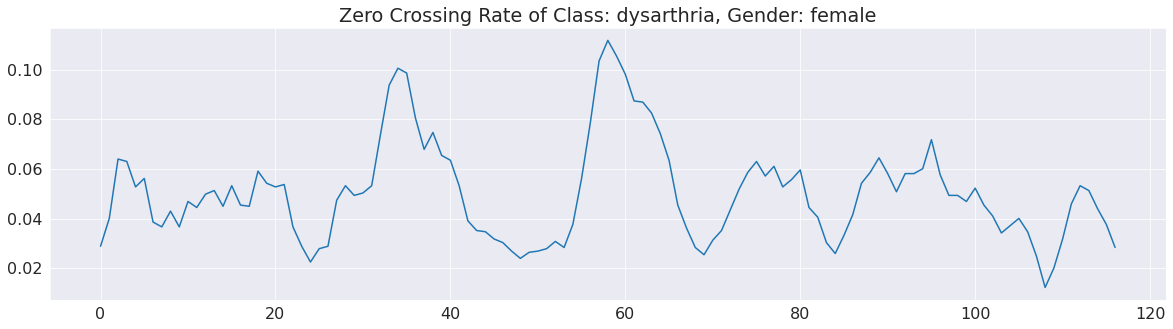

Sum of zero crossing  6223


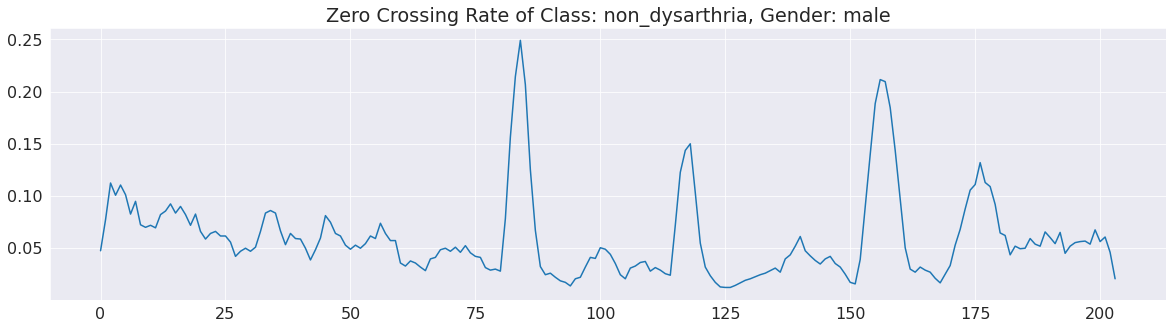

Sum of zero crossing  2035


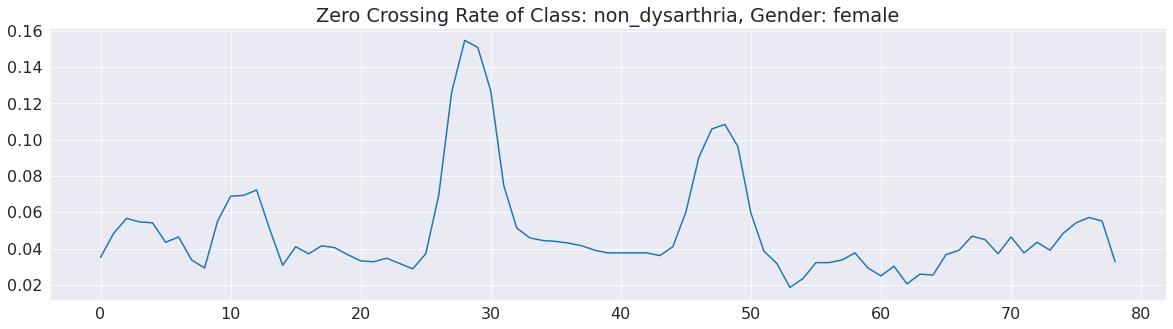

In [11]:
show_zcr(male_dysarthric.iloc[0].filename, male_dysarthric.iloc[0].is_dysarthria, male_dysarthric.iloc[0].gender)
show_zcr(female_dysarthric.iloc[0].filename, female_dysarthric.iloc[0].is_dysarthria, female_dysarthric.iloc[0].gender)
show_zcr(male_ndysarthric.iloc[0].filename, male_ndysarthric.iloc[0].is_dysarthria, male_ndysarthric.iloc[0].gender)
show_zcr(female_ndysarthric.iloc[0].filename, female_ndysarthric.iloc[0].is_dysarthria, female_ndysarthric.iloc[0].gender)

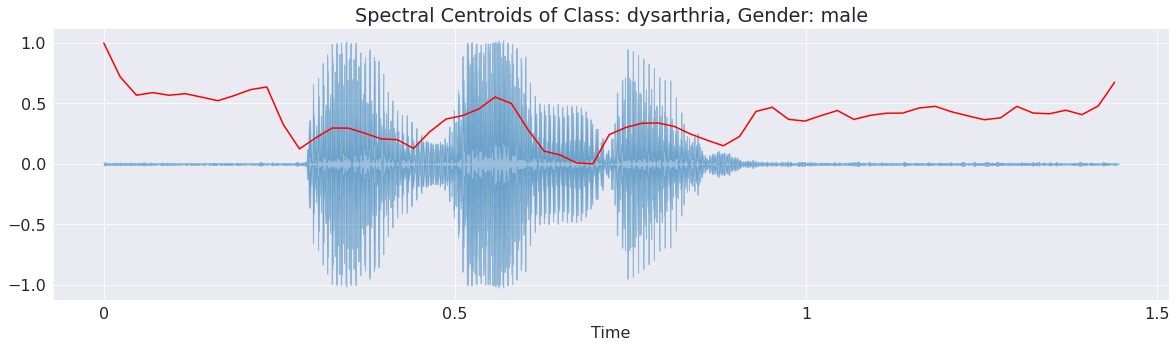

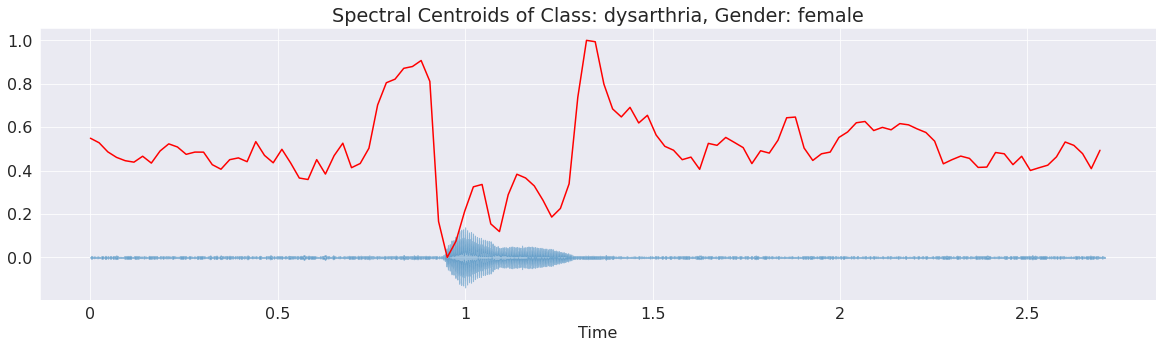

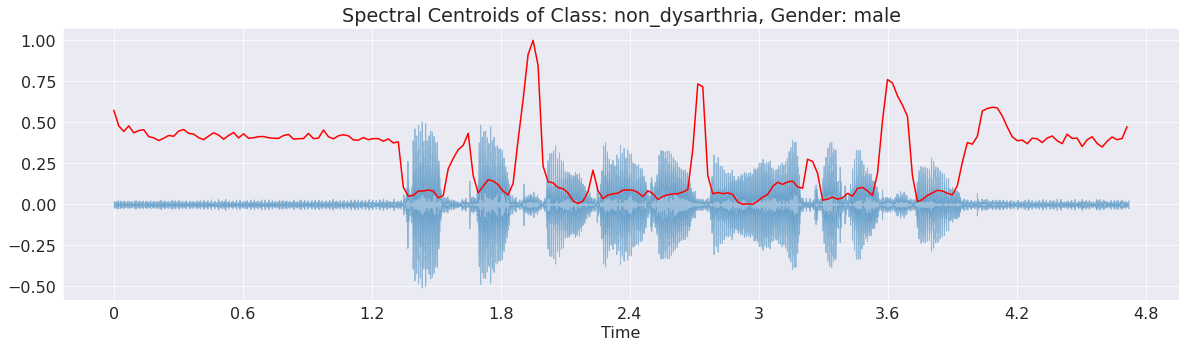

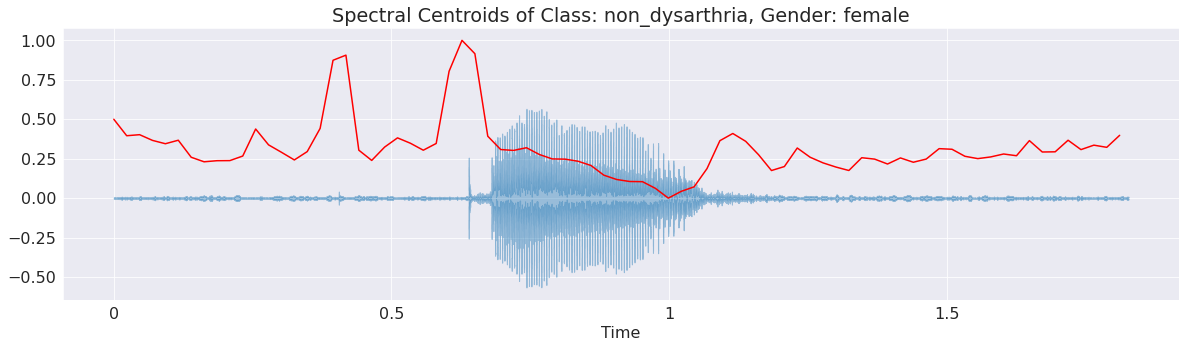

In [12]:
show_spectral_centroids(male_dysarthric.iloc[0].filename, male_dysarthric.iloc[0].is_dysarthria, male_dysarthric.iloc[0].gender)
show_spectral_centroids(female_dysarthric.iloc[0].filename, female_dysarthric.iloc[0].is_dysarthria, female_dysarthric.iloc[0].gender)
show_spectral_centroids(male_ndysarthric.iloc[0].filename, male_ndysarthric.iloc[0].is_dysarthria, male_ndysarthric.iloc[0].gender)
show_spectral_centroids(female_ndysarthric.iloc[0].filename, female_ndysarthric.iloc[0].is_dysarthria, female_ndysarthric.iloc[0].gender)

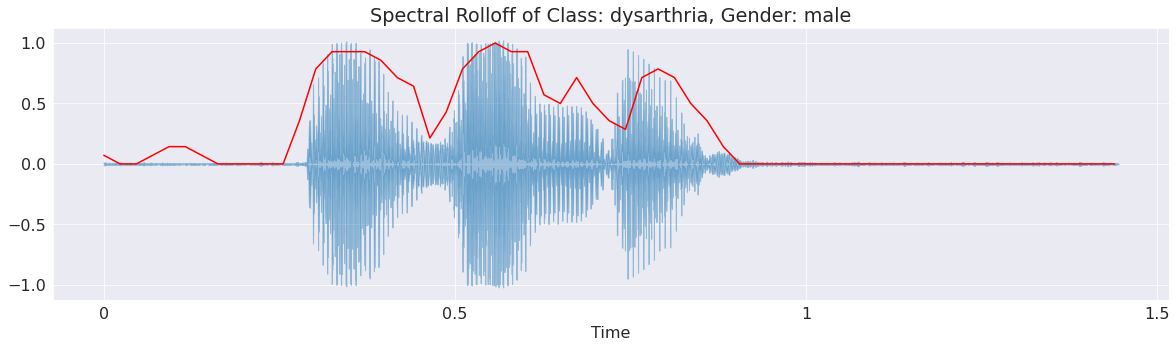

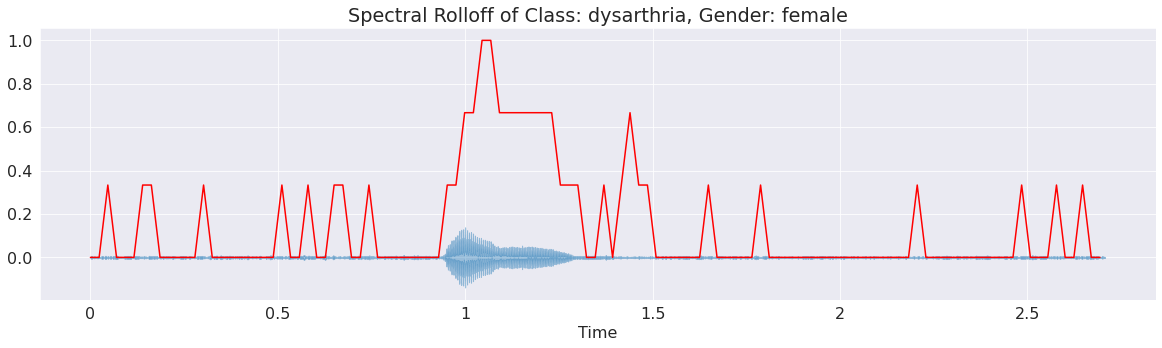

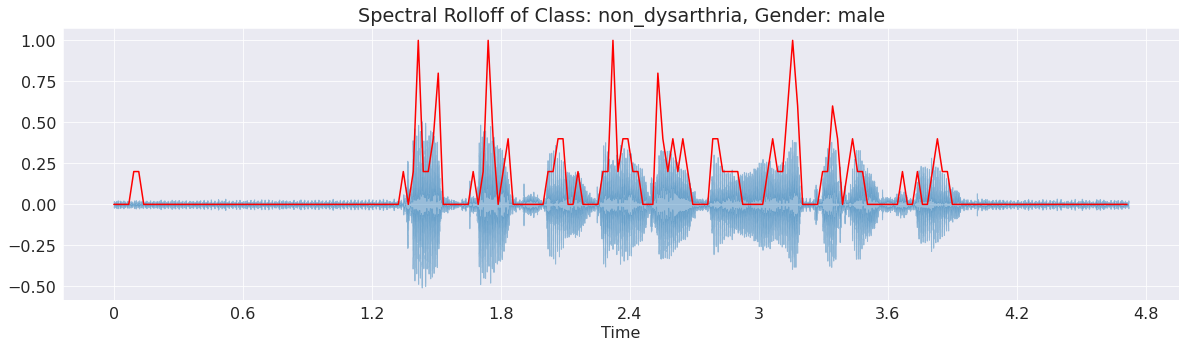

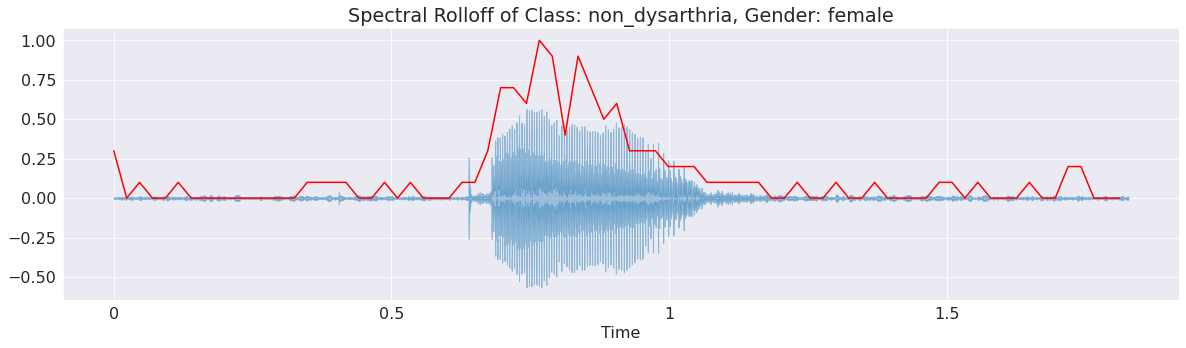

In [13]:
show_spectral_rolloff(male_dysarthric.iloc[0].filename, male_dysarthric.iloc[0].is_dysarthria, male_dysarthric.iloc[0].gender)
show_spectral_rolloff(female_dysarthric.iloc[0].filename, female_dysarthric.iloc[0].is_dysarthria, female_dysarthric.iloc[0].gender)
show_spectral_rolloff(male_ndysarthric.iloc[0].filename, male_ndysarthric.iloc[0].is_dysarthria, male_ndysarthric.iloc[0].gender)
show_spectral_rolloff(female_ndysarthric.iloc[0].filename, female_ndysarthric.iloc[0].is_dysarthria, female_ndysarthric.iloc[0].gender)

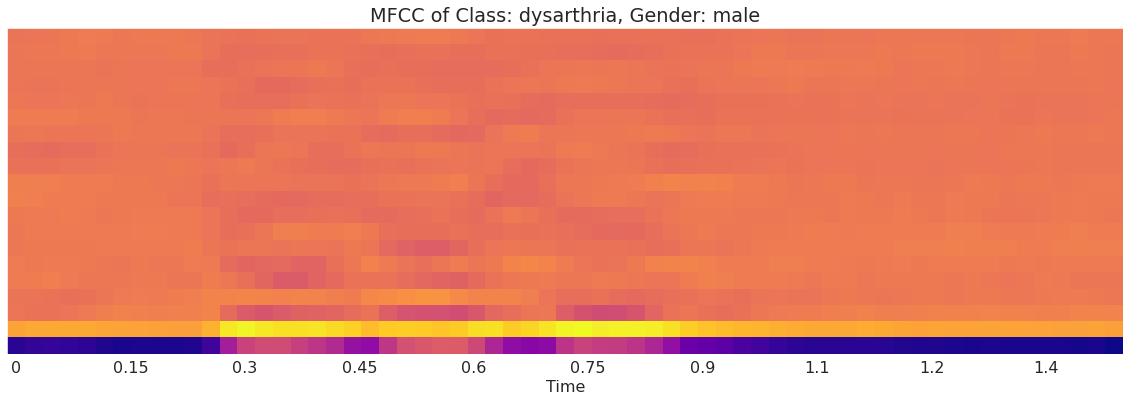

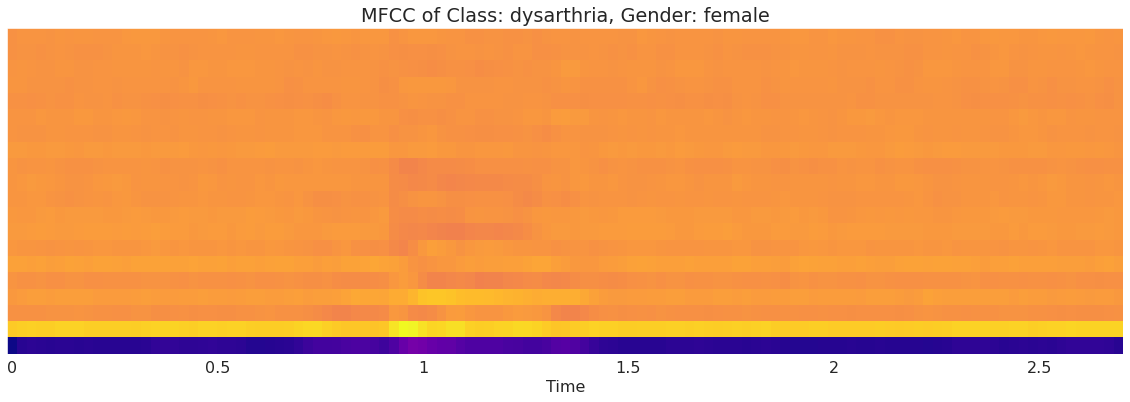

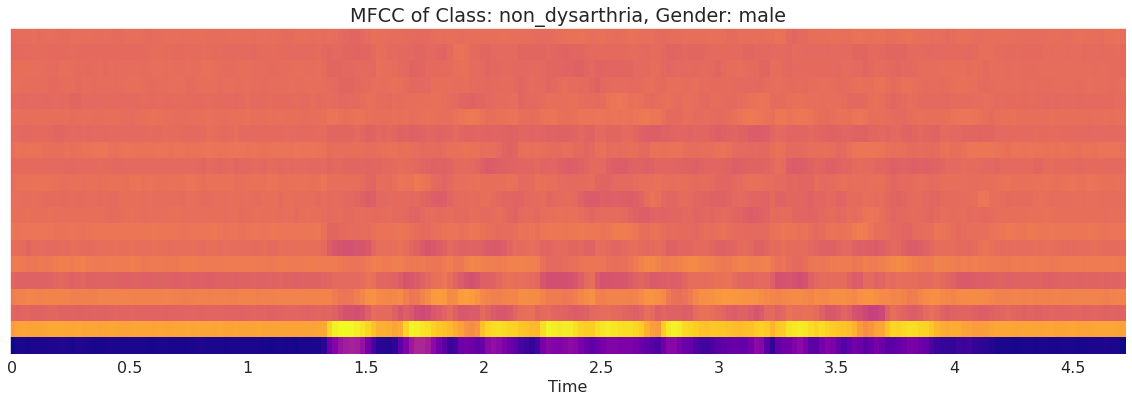

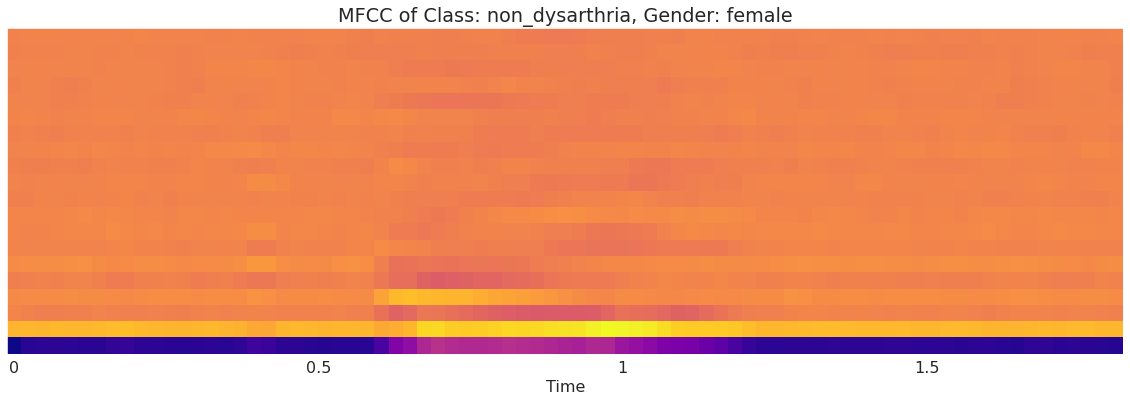

In [14]:
show_mfccs(male_dysarthric.iloc[0].filename, male_dysarthric.iloc[0].is_dysarthria, male_dysarthric.iloc[0].gender)
show_mfccs(female_dysarthric.iloc[0].filename, female_dysarthric.iloc[0].is_dysarthria, female_dysarthric.iloc[0].gender)
show_mfccs(male_ndysarthric.iloc[0].filename, male_ndysarthric.iloc[0].is_dysarthria, male_ndysarthric.iloc[0].gender)
show_mfccs(female_ndysarthric.iloc[0].filename, female_ndysarthric.iloc[0].is_dysarthria, female_ndysarthric.iloc[0].gender)

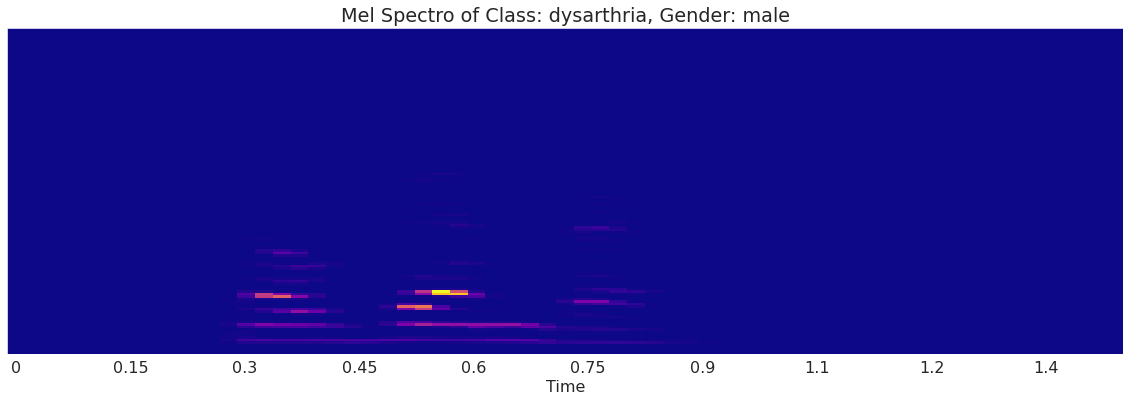

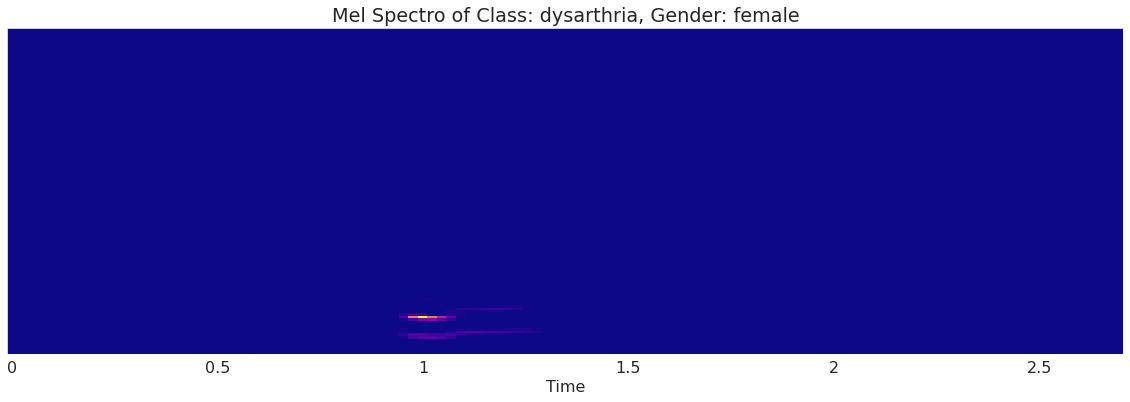

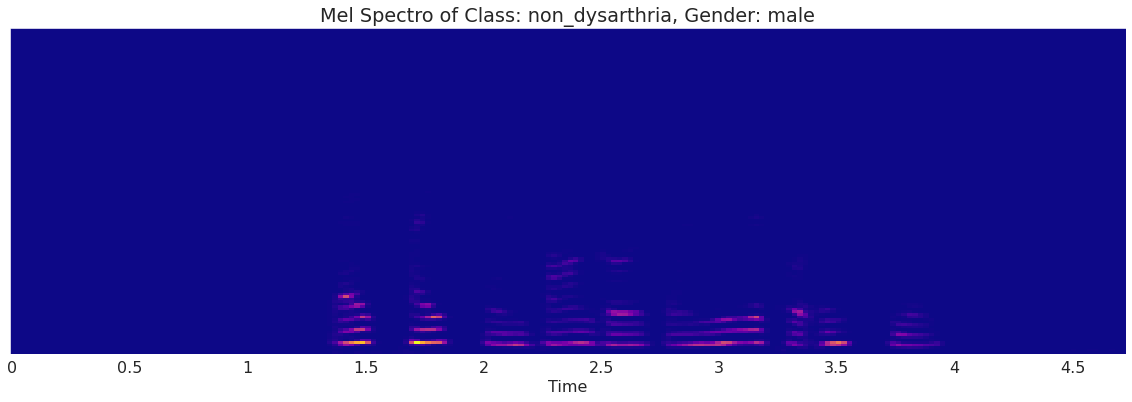

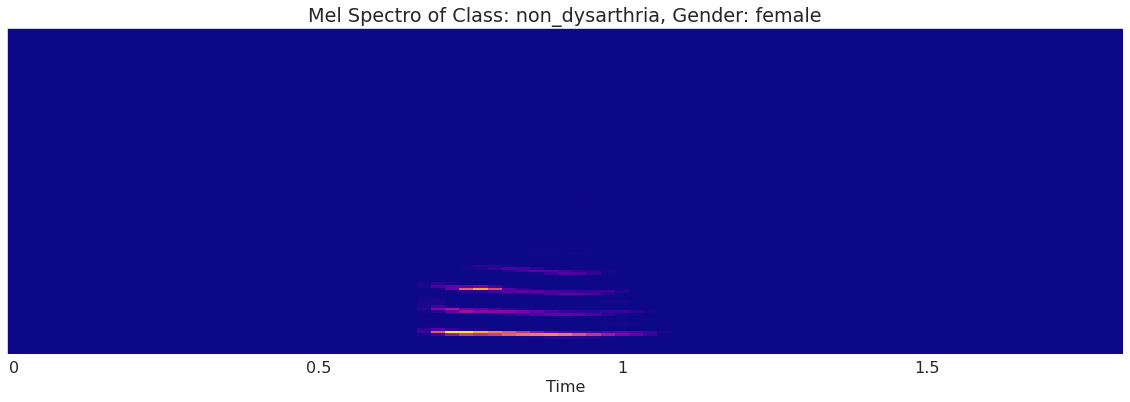

In [15]:
show_melspectro(male_dysarthric.iloc[0].filename, male_dysarthric.iloc[0].is_dysarthria, male_dysarthric.iloc[0].gender)
show_melspectro(female_dysarthric.iloc[0].filename, female_dysarthric.iloc[0].is_dysarthria, female_dysarthric.iloc[0].gender)
show_melspectro(male_ndysarthric.iloc[0].filename, male_ndysarthric.iloc[0].is_dysarthria, male_ndysarthric.iloc[0].gender)
show_melspectro(female_ndysarthric.iloc[0].filename, female_ndysarthric.iloc[0].is_dysarthria, female_ndysarthric.iloc[0].gender)

In [16]:
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, recall_score

In [17]:
def feature_extraction(df):
    features = []
    for i,record in tqdm(df.iterrows(),total=df.shape[0]):
        try:
            x , sr = librosa.load(record['filename'])
            mean_mfcc = np.mean(librosa.feature.mfcc(y=x, sr=sr, n_mfcc=128),axis=1)
            features.append(mean_mfcc)
        except EOFError:
            pass
        
    dataf = pd.DataFrame(features)
    dataf['class'] = df['is_dysarthria']
    return dataf

In [18]:
dataf = feature_extraction(data)

100%|██████████| 4316/4316 [17:36<00:00,  4.09it/s]


In [19]:
dataf

,0,1,2,3,4,5,6,7,8,9,...,119,120,121,122,123,124,125,126,127,class
0,-398.970551,92.846680,-6.212745,19.836878,-3.015201,9.478265,5.134083,6.716100,1.437088,0.016323,...,0.018726,-0.244671,-0.650705,-0.262222,0.137795,-0.539087,-0.257223,-0.230522,-0.188446,dysarthria
1,-232.392548,115.044525,-21.028315,39.190132,-17.016842,7.619745,-2.724971,4.140653,-1.230497,-0.977594,...,0.197640,0.564010,0.166091,-0.022294,0.257573,0.168773,0.264451,-0.257519,-0.390595,dysarthria
2,-466.484497,89.272385,-8.458461,30.776363,-11.168960,18.305796,0.989266,10.417193,0.574027,1.563966,...,0.232031,0.074036,0.237405,0.154122,0.281900,0.768758,-0.073312,0.096406,0.285212,dysarthria
3,-466.735046,62.805061,12.439709,29.304922,12.614448,9.676723,1.418015,13.074185,0.037665,3.573357,...,0.408432,-0.018611,-0.274066,0.071348,0.231881,0.456909,0.000649,-0.379244,-0.105873,dysarthria
4,-426.449707,80.985413,-4.792509,36.350883,-0.092283,19.156744,-5.060070,10.123955,2.196594,1.254182,...,-0.064134,0.120973,0.070115,0.138273,0.084424,0.080933,-0.295089,-0.199056,0.120445,dysarthria
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4309,-469.044403,118.562874,-6.434429,31.259987,-6.916942,28.232567,4.596171,10.801232,10.187455,2.826132,...,1.427834,1.057893,1.556124,0.044795,0.736732,-0.084226,-0.271552,0.629459,0.242347,dysarthria
4310,-341.552185,125.433670,-18.731533,38.031948,-17.117916,14.470189,0.926031,7.484399,4.782696,0.356445,...,1.192693,0.387493,0.853776,0.574696,0.120452,0.950003,0.213699,0.169374,0.082446,dysarthria
4311,-452.753052,124.908340,-12.018002,27.919792,-9.511669,26.848291,5.744361,11.316424,5.834332,3.948838,...,1.109973,1.165894,1.393030,-0.012943,0.496955,-0.252641,-0.252282,0.796462,0.615387,dysarthria
4312,-262.515747,121.906532,-20.538330,48.941536,-24.940454,35.154140,-8.200293,17.075691,7.877915,0.870777,...,1.850283,1.768507,0.825172,0.101314,-0.407541,-0.048040,0.122928,-0.037107,-0.407376,dysarthria


In [37]:

dataf.to_csv("MFCCoutput.csv") 
